In [1]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

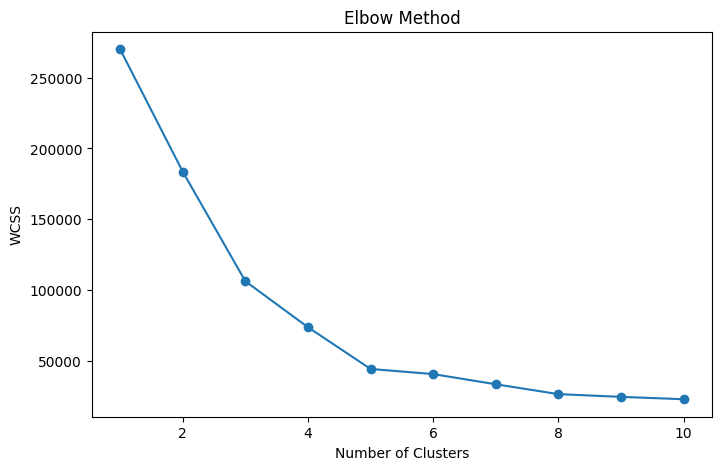

In [5]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [6]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

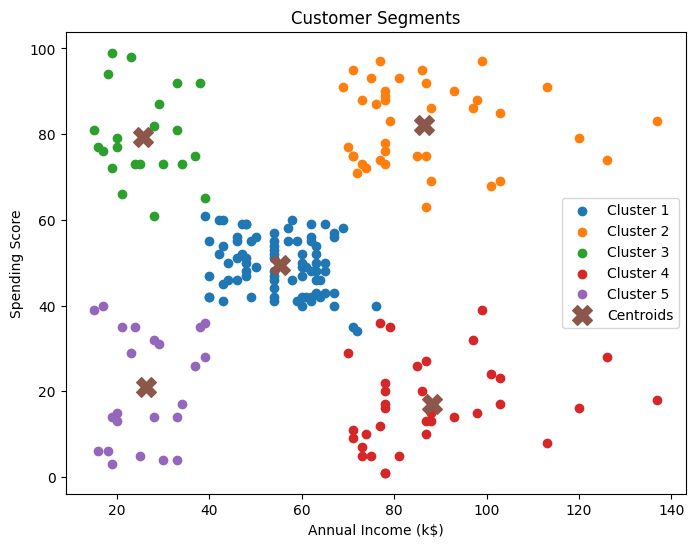

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[y_kmeans == 0, 0],
    X.iloc[y_kmeans == 0, 1],
    label='Cluster 1'
)

plt.scatter(
    X.iloc[y_kmeans == 1, 0],
    X.iloc[y_kmeans == 1, 1],
    label='Cluster 2'
)

plt.scatter(
    X.iloc[y_kmeans == 2, 0],
    X.iloc[y_kmeans == 2, 1],
    label='Cluster 3'
)

plt.scatter(
    X.iloc[y_kmeans == 3, 0],
    X.iloc[y_kmeans == 3, 1],
    label='Cluster 4'
)

plt.scatter(
    X.iloc[y_kmeans == 4, 0],
    X.iloc[y_kmeans == 4, 1],
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.show()